Sakkady: 138/138 dopasowań w oknie 500 ms, maksimum 457 ms -> latency_window_saccade.png
Mrugnięcia: 106/110 dopasowań w oknie 1000 ms, maksimum 1049 ms -> latency_window_blink.png


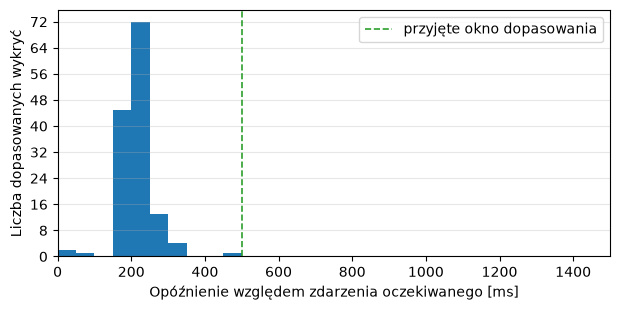

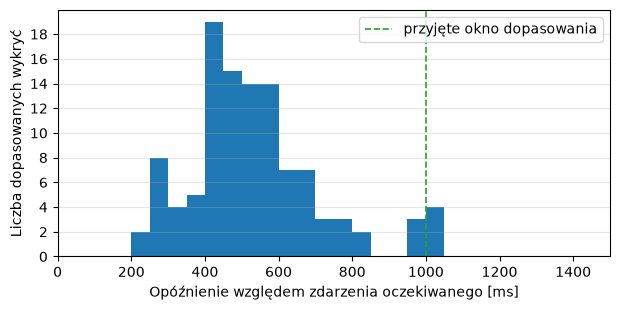

In [3]:
import sys

sys.path.insert(0, ".")
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator

from src.analyze import analyze_file
from src.detection_config import DetectionConfig, ScenarioConfig
from src.ground_truth import (
    build_expected_blinks,
    build_expected_saccades,
    match_expected_to_detected,
)
from src.io_utils import collect_csv_files

# odstęp metronomu i odstęp między przemieszczeniami celu wynoszą 1,5 s, więc
# jest to najszersze okno, które nie przypisze wykrycia do kolejnego bodźca
MAX_WINDOW_S = 1.5
BIN_WIDTH_MS = 50
PANELS = [
    ("saccade", 500, "Sakkady", "latency_window_saccade.png"),
    ("blink", 1000, "Mrugnięcia", "latency_window_blink.png"),
]

detection_cfg = DetectionConfig()
scenario_cfg = ScenarioConfig()

saccade_matches, blink_matches = [], []
for path in collect_csv_files(Path("data")):
    samples, events = analyze_file(path, detection_cfg)
    saccade_matches.append(
        match_expected_to_detected(
            build_expected_saccades(samples), events, MAX_WINDOW_S
        )
    )
    blink_matches.append(
        match_expected_to_detected(
            build_expected_blinks(samples, scenario_cfg), events, MAX_WINDOW_S
        )
    )

matches_by_gesture = {
    "saccade": pd.concat(saccade_matches, ignore_index=True),
    "blink": pd.concat(blink_matches, ignore_index=True),
}

bins = np.arange(0, MAX_WINDOW_S * 1000 + BIN_WIDTH_MS, BIN_WIDTH_MS)

for gesture, window_ms, title, filename in PANELS:
    matches = matches_by_gesture[gesture]
    # scenariusz łączony omówiony jest osobno, poza zbiorczymi miarami
    matches = matches[matches["scenario"] != "combined"]
    latencies = matches.loc[matches["detected"], "latency_ms"]

    fig, ax = plt.subplots(figsize=(6.3, 3.2))
    ax.hist(latencies, bins=bins, color="tab:blue")
    ax.axvline(
        window_ms,
        color="tab:green",
        linestyle="--",
        linewidth=1.2,
        label="przyjęte okno dopasowania",
    )
    ax.set_xlim(0, MAX_WINDOW_S * 1000)
    ax.set_xlabel("Opóźnienie względem zdarzenia oczekiwanego [ms]")
    ax.set_ylabel("Liczba dopasowanych wykryć")
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(axis="y", alpha=0.3)
    ax.legend(loc="upper right")
    fig.tight_layout()
    fig.savefig(filename, dpi=200)

    within = int((latencies <= window_ms).sum())
    print(
        f"{title}: {within}/{len(latencies)} dopasowań w oknie {window_ms} ms, "
        f"maksimum {latencies.max():.0f} ms -> {filename}"
    )

plt.show()